# 3C — XGBoost Regressor

**Project:** Predictive Modeling of US Used Vehicle Prices  
**Course:** ENGR422 — Applied Machine Learning  
**Author:** Eren Acar Başaran (83179)  

---

This notebook covers the **XGBoost Regressor** from **Work Package 3 — Model Implementation**.

**Deliverable:** D3.2 — Tuned Ensemble Models (XGBoost portion)

## 3C.1 — Imports & Load Preprocessed Data

Import the preprocessing pipeline built in Notebook 02. Load the dataset and reproduce the exact same train-test split (same `random_state`). Also import `xgboost`.

**Code organization note.** Like 03a, this notebook imports shared helpers from `src/utils.py` (`load_train`, `load_preprocessor`, `MODELS_DIR`, `RANDOM_STATE`). All model notebooks (03a, 03c, 04) use the same loaders so the train/test splits and preprocessor instances are byte-identical across the comparison — this prevents subtle apples-to-oranges bugs in §04's cross-model evaluation.

In [1]:
import sys
import time

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline

import xgboost as xgb

# src/ holds shared project utilities (utils.py) and the custom-transformer
# classes that joblib.load needs to resolve (preprocessing.py).
sys.path.insert(0, "../src")
import preprocessing  # noqa: F401  -- needed so joblib.load resolves custom transformers
from utils import load_train, load_preprocessor, MODELS_DIR, RANDOM_STATE

X_train, y_train = load_train()

# Tree-variant preprocessor: no scaling, no log transform on odometer.
# Trees are scale-invariant, so passthrough on numerics keeps year/odometer
# in their raw, interpretable units when reading split thresholds.
preprocessor_tree = load_preprocessor("tree")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Raw features ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"Loaded preprocessor: {type(preprocessor_tree).__name__} "
      f"with steps {[name for name, _ in preprocessor_tree.steps]}")
print(f"xgboost version: {xgb.__version__}")


X_train: (305141, 12)
y_train: (305141,)
Raw features (12): ['year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Loaded preprocessor: Pipeline with steps ['impute', 'encode']
xgboost version: 3.2.0


## 3C.2 — Model Setup

Attach `XGBRegressor` as the estimator in the pipeline. Use `tree_method='hist'` for efficient training on the large dataset. Set a baseline configuration before tuning.

In [2]:
# Baseline XGBoost configuration. These defaults are the reference point
# for §3C.3 (default-hyperparameter training); §3C.4 then runs
# RandomizedSearchCV around this baseline to find the tuned model used in
# §3C.5 and saved in §3C.8.
#
# tree_method="hist" — histogram-based splits, ~10x faster than the exact
#   method on a dataset this size (~305K rows). Required for practical
#   tuning runs within the SLURM time budget.
# objective="reg:squarederror" — standard regression objective; the project's
#   reporting metric is MAE, but XGBoost optimizes squared error during fitting
#   and we evaluate with MAE downstream.
# n_jobs=-1 — use all CPUs allocated by the SLURM job.
xgb_baseline = xgb.XGBRegressor(
    tree_method="hist",
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# Pipeline mirrors 03a's structure: clone the loaded preprocessor so each
# .fit() (including every CV fold) refits preprocessing on its own training
# partition — keeps MeanTargetEncoder leakage-free.
xgb_pipeline = Pipeline([
    ("prep", clone(preprocessor_tree)),
    ("est",  xgb_baseline),
])

xgb_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('est', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('encode', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('year_imp', ...), ('odo_imp', ...), ...]"
,"transform_input transform

## 3C.3 — Baseline Training (Default Hyperparameters)

Fit `xgb_pipeline` (from §3C.2) on the full training set with default hyperparameters, then run 5-fold cross-validation. This establishes the **no-tuning reference point** that §3C.4 (RandomizedSearchCV) needs to beat — if tuning doesn't improve MAE meaningfully over this baseline, the search space or budget is wrong. Reports per-fold MAE and R² plus mean ± std.


In [3]:
from sklearn.model_selection import cross_validate

# Fit the baseline pipeline on the full training set. The fitted version is
# kept around for §3C.6 (feature importance) and §3C.7 (overfitting
# analysis vs the tuned model from §3C.5).
print(f"Fitting baseline XGBoost on {X_train.shape[0]:,} rows ...")
t0 = time.perf_counter()
xgb_pipeline.fit(X_train, y_train)
baseline_fit_time = time.perf_counter() - t0
print(f"  done in {baseline_fit_time:.1f}s")

# 5-fold CV with MAE (project's primary metric) + R^2 for context.
# cross_validate clones per fold so the cloned preprocessor refits on each
# fold's training partition only -- MeanTargetEncoder cannot leak.
print("\n5-fold cross-validation (default hyperparameters) ...")
res = cross_validate(
    xgb_pipeline, X_train, y_train,
    cv=5,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
    n_jobs=-1,
)

baseline_mae = -res["test_mae"]   # flip sign back to positive ($)
baseline_r2  =  res["test_r2"]

print(f"\n  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in baseline_mae))
print(f"  R^2 per fold: " + ", ".join(f" {r:.4f}" for r in baseline_r2))
print(f"\nBaseline summary:")
print(f"  CV MAE = ${baseline_mae.mean():,.2f} \u00b1 ${baseline_mae.std():,.2f}")
print(f"  CV R^2 = {baseline_r2.mean():.4f} \u00b1 {baseline_r2.std():.4f}")


Fitting baseline XGBoost on 305,141 rows ...


  done in 3.4s

5-fold cross-validation (default hyperparameters) ...



  MAE per fold: $  3,219, $  3,236, $  3,261, $  3,256, $  3,258
  R^2 per fold:  0.8485,  0.8444,  0.8425,  0.8483,  0.8406

Baseline summary:
  CV MAE = $3,246.08 ± $16.09
  CV R^2 = 0.8449 ± 0.0031


## 3C.4 — Hyperparameter Tuning

`RandomizedSearchCV` over a continuous search space — XGBoost has 7–8 sensible knobs and an exhaustive grid of even modest sizes blows past the SLURM time budget (5⁷ ≈ 78k combinations × 5 folds at ~15s each ≈ days). Random sampling finds nearly-as-good hyperparameters using a tiny fraction of that budget (Bergstra & Bengio, 2012).

Sampled space:
- `n_estimators` (`randint(100, 800)`) — number of boosting rounds.
- `max_depth` (`randint(3, 10)`) — tree depth; shallower = more bias, less variance.
- `learning_rate` (`loguniform(0.01, 0.3)`) — shrinkage; trades off with `n_estimators`.
- `subsample`, `colsample_bytree` (`uniform(0.6, 0.4)` → 0.6–1.0) — row and column sampling per tree.
- `min_child_weight` (`randint(1, 10)`) — regularization on leaf splits.
- `reg_alpha` (`loguniform(1e-3, 1)`) — L1 penalty on leaf weights.
- `reg_lambda` (`loguniform(0.1, 10)`) — L2 penalty on leaf weights.

Scoring is `neg_mean_absolute_error` to match the project's primary metric. The estimator is the same `Pipeline(prep + est)` as §3C.2 so the cloned preprocessor refits on each fold (leakage-safe `MeanTargetEncoder`). After fitting, `refit=True` retrains the best estimator on the full training set and exposes it as `xgb_search.best_estimator_`.


Starting RandomizedSearchCV: 30 samples x 5 folds = 150 fits ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


  done in 3.5 min

Best CV MAE: $2,555.15
Best params:
  colsample_bytree   0.6391
  learning_rate      0.1025
  max_depth          9
  min_child_weight   7
  n_estimators       527
  reg_alpha          0.03059
  reg_lambda         0.1172
  subsample          0.9637

Improvement over baseline (default hyperparameters):
  baseline CV MAE = $3,246.08
  tuned    CV MAE = $2,555.15
  delta           = $690.94


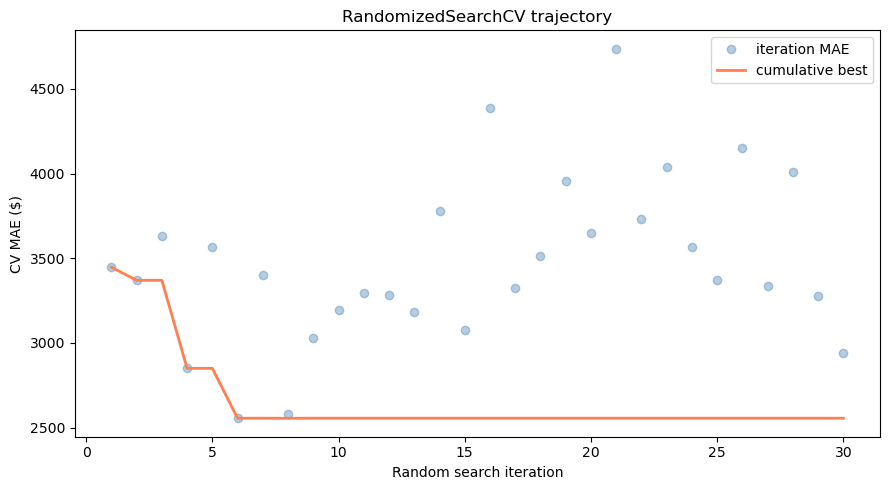

In [4]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV

# Search budget. 30 samples * 5 folds = 150 fits. With tree_method='hist'
# each fit on this dataset takes ~10-20s, so wall-clock is <30 min on the
# 16-CPU SLURM allocation. Bump N_ITER for a more thorough sweep.
N_ITER = 30

param_distributions = {
    "est__n_estimators":     randint(100, 800),
    "est__max_depth":        randint(3, 10),         # 3-9; industry-standard XGB range
    "est__learning_rate":    loguniform(0.01, 0.3),
    "est__subsample":        uniform(0.6, 0.4),     # 0.6 to 1.0
    "est__colsample_bytree": uniform(0.6, 0.4),     # 0.6 to 1.0
    "est__min_child_weight": randint(1, 10),
    "est__reg_alpha":        loguniform(1e-3, 1.0),
    "est__reg_lambda":       loguniform(0.1, 10.0),
}

# Fresh pipeline -- clone() guarantees the preprocessor refits per fold so
# MeanTargetEncoder cannot leak validation labels. Inner n_jobs=1 because
# the outer RandomizedSearchCV is what parallelizes (n_jobs=-1 below);
# nesting parallelism would oversubscribe the CPUs.
xgb_search = RandomizedSearchCV(
    Pipeline([
        ("prep", clone(preprocessor_tree)),
        ("est",  xgb.XGBRegressor(
            tree_method="hist",
            objective="reg:squarederror",
            n_jobs=1,
            random_state=RANDOM_STATE,
        )),
    ]),
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
    return_train_score=True,   # used in S3C.7 to measure train-vs-CV gap
)

print(f"Starting RandomizedSearchCV: {N_ITER} samples x 5 folds = {N_ITER * 5} fits ...")
t0 = time.perf_counter()
xgb_search.fit(X_train, y_train)
search_time = time.perf_counter() - t0
print(f"  done in {search_time/60:.1f} min")

best_mae = -xgb_search.best_score_
print(f"\nBest CV MAE: ${best_mae:,.2f}")
print("Best params:")
for k, v in xgb_search.best_params_.items():
    val = f"{v:.4g}" if isinstance(v, float) else v
    print(f"  {k.removeprefix('est__'):<18} {val}")

# Compare to the no-tuning reference from S3C.3
print(f"\nImprovement over baseline (default hyperparameters):")
print(f"  baseline CV MAE = ${baseline_mae.mean():,.2f}")
print(f"  tuned    CV MAE = ${best_mae:,.2f}")
print(f"  delta           = ${baseline_mae.mean() - best_mae:,.2f}")


# Tuning trajectory: cumulative-best CV MAE as the search proceeds.
# Useful presentation visual -- shows whether 30 iterations was enough.
import matplotlib.pyplot as plt
mae_per_iter = -xgb_search.cv_results_["mean_test_score"]   # neg-MAE -> $
best_so_far  = np.minimum.accumulate(mae_per_iter)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(mae_per_iter) + 1), mae_per_iter, "o", alpha=0.4,
        color="steelblue", label="iteration MAE")
ax.plot(range(1, len(best_so_far) + 1), best_so_far, "-", color="coral",
        linewidth=2, label="cumulative best")
ax.set_xlabel("Random search iteration")
ax.set_ylabel("CV MAE ($)")
ax.set_title("RandomizedSearchCV trajectory")
ax.legend()
plt.tight_layout()
plt.show()


## 3C.5 — Train Best Model

`RandomizedSearchCV(refit=True)` already exposed the tuned, full-training-set-fit pipeline as `xgb_search.best_estimator_`. We pin it to a clean handle (`best_pipeline`) and run one explicit 5-fold CV with the chosen hyperparameters so the per-fold MAE and R² numbers used downstream (§3C.6 importance, §3C.7 overfit, §04 evaluation) come from a single, well-scoped pass — not from `cv_results_` which mixes per-iteration outputs.


5-fold CV on the tuned XGBoost ...



  MAE per fold: $  2,533, $  2,562, $  2,581, $  2,545, $  2,555
  R^2 per fold:  0.8868,  0.8839,  0.8801,  0.8877,  0.8813

Tuned XGBoost (final):
  CV MAE = $2,555.15 ± $16.16
  CV R^2 = 0.8839 ± 0.0030

Generating out-of-fold predictions for diagnostic plots ...


  done in 0.4 min


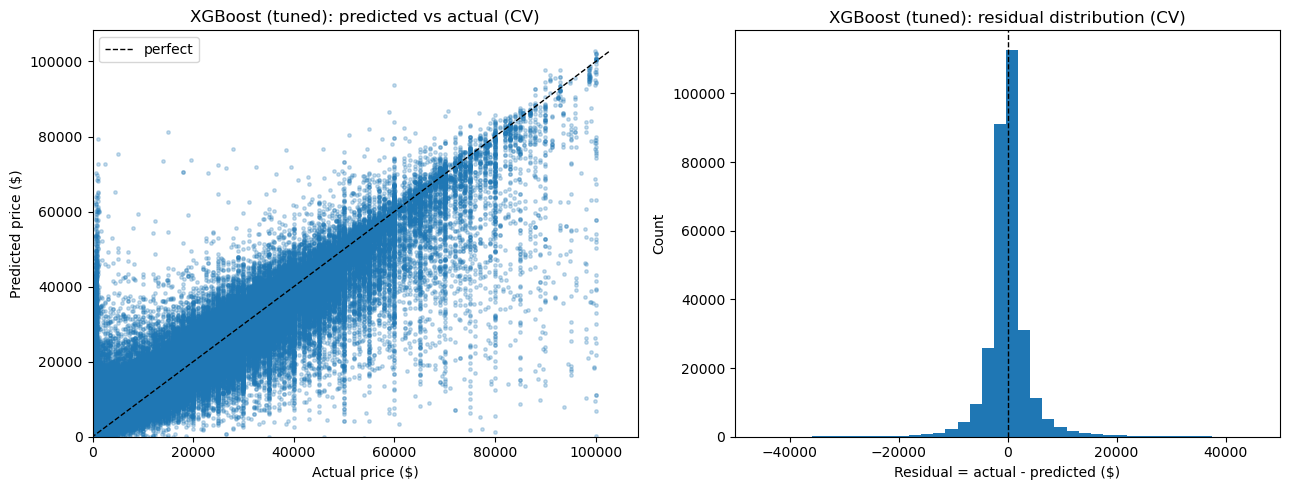

In [5]:
# `refit=True` on RandomizedSearchCV (set in S3C.4) means best_estimator_ is
# already a Pipeline trained with the winning hyperparameters on the full
# X_train. Pinning to a stable handle for downstream sections.
best_pipeline = xgb_search.best_estimator_

# Run one final 5-fold CV with the chosen hyperparameters so our reported
# numbers come from a single, clean pass rather than scraping cv_results_.
print("5-fold CV on the tuned XGBoost ...")
res = cross_validate(
    best_pipeline, X_train, y_train,
    cv=5,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
    n_jobs=-1,
    return_train_score=True,
)

tuned_mae       = -res["test_mae"]
tuned_r2        =  res["test_r2"]
tuned_train_mae = -res["train_mae"]   # used in S3C.7 overfit analysis

print(f"\n  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in tuned_mae))
print(f"  R^2 per fold: " + ", ".join(f" {r:.4f}" for r in tuned_r2))
print(f"\nTuned XGBoost (final):")
print(f"  CV MAE = ${tuned_mae.mean():,.2f} \u00b1 ${tuned_mae.std():,.2f}")
print(f"  CV R^2 = {tuned_r2.mean():.4f} \u00b1 {tuned_r2.std():.4f}")


# Diagnostic plots on out-of-fold predictions (no test-set leakage).
# Same pair as 03a -- using utils helpers keeps the visual style consistent
# across model notebooks for the presentation deck.
from sklearn.model_selection import cross_val_predict
from utils import plot_pred_vs_actual, plot_residuals

print("\nGenerating out-of-fold predictions for diagnostic plots ...")
t0 = time.perf_counter()
y_pred_cv = cross_val_predict(best_pipeline, X_train, y_train, cv=5, n_jobs=-1)
print(f"  done in {(time.perf_counter() - t0)/60:.1f} min")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pred_vs_actual(y_train, y_pred_cv, ax=axes[0],
                    title="XGBoost (tuned): predicted vs actual (CV)")
plot_residuals(y_train, y_pred_cv, ax=axes[1],
               title="XGBoost (tuned): residual distribution (CV)")
# Prices and predicted prices are >= 0 -- pin scatter axes to start at 0.
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)
# Constrain residual view to +/- 50k for readability.
axes[1].set_xlim(-50_000, 50_000)
plt.tight_layout()
plt.show()


## 3C.6 — Feature Importance

XGBoost exposes `feature_importances_` on the fitted estimator — gain-based by default (the average reduction in loss across all splits that used the feature, weighted by node coverage). We extract them from the tuned model and visualize the top 15 using `utils.plot_feature_importances` so the chart matches what 03a/04 produce for their respective models.

Feature names are constructed manually from the encode `ColumnTransformer` rather than via `get_feature_names_out()` — the saved preprocessor pickle contains a `FunctionTransformer(log1p)` and custom imputers that don't all expose feature-name-out, so manual walking is the robust option.


Top 15 features by XGBoost gain importance:
                  feature  importance
            target__model    0.183793
           ohe__drive_fwd    0.160934
               year__year    0.086190
            ohe__fuel_gas    0.075323
  ohe__transmission_other    0.042056
          ohe__type_truck    0.037327
ohe__title_status_salvage    0.033650
          ohe__fuel_other    0.032242
ohe__title_status_rebuilt    0.031700
            odo__odometer    0.030559
          ohe__type_other    0.025007
         ohe__type_pickup    0.022163
          ohe__type_sedan    0.021453
     target__manufacturer    0.020325
ohe__title_status_missing    0.019598


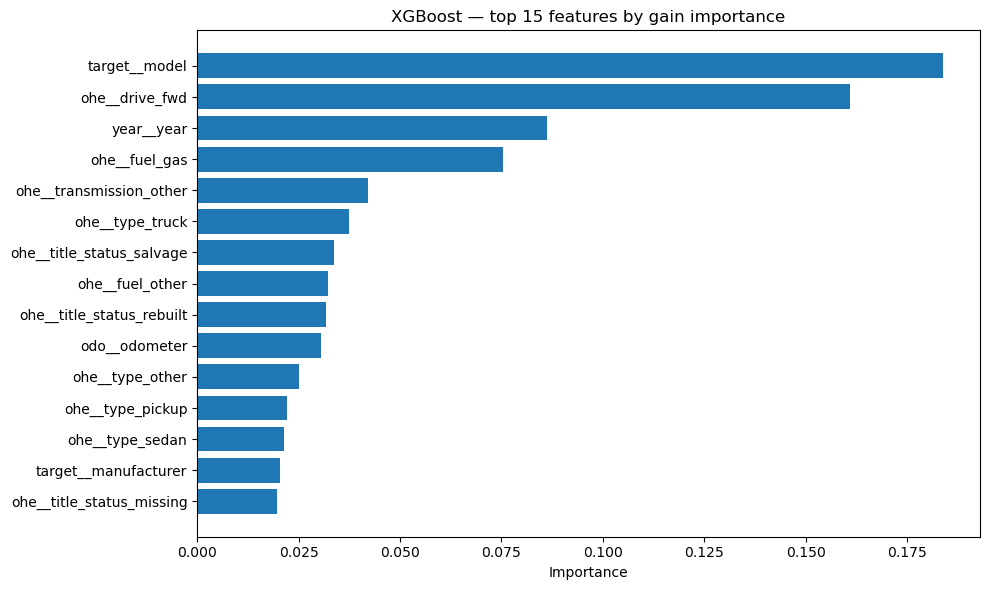

In [6]:
from utils import plot_feature_importances

# Build the 32 post-preprocessing feature names by walking the encode
# ColumnTransformer's transformers_ list (same approach as 03a).
encode = best_pipeline.named_steps["prep"].named_steps["encode"]
_parts = []
for tname, trans, cols in encode.transformers_:
    if tname == "ohe":
        ohe_names = encode.named_transformers_["ohe"].get_feature_names_out(cols)
        _parts.extend(f"ohe__{n}" for n in ohe_names)
    else:
        _parts.extend(f"{tname}__{c}" for c in cols)
feat_names = np.asarray(_parts)

importances = best_pipeline.named_steps["est"].feature_importances_
assert len(importances) == len(feat_names), \
    f"importance count {len(importances)} != feature-name count {len(feat_names)}"

# Top 15 table
top_idx = np.argsort(importances)[::-1][:15]
print("Top 15 features by XGBoost gain importance:")
print(pd.DataFrame({
    "feature":    feat_names[top_idx],
    "importance": importances[top_idx],
}).to_string(index=False))

# Plot via utils for cross-notebook consistency
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
plot_feature_importances(importances, feat_names, n=15, ax=ax,
                         title="XGBoost — top 15 features by gain importance")
plt.tight_layout()
plt.show()


## 3C.7 — Overfitting Analysis

The train-vs-CV gap is a direct overfitting signal: if the model fits training data dramatically better than held-out folds, it has memorized noise. We compute the gap from §3C.5's `return_train_score=True` CV pass — same folds, same hyperparameters, both train and validation scores already in hand.

Rule of thumb for tabular regression on dataset of this size: a gap below ~10 % of the mean MAE is comfortable, 10–25 % is acceptable, anything larger suggests the model needs more regularization or a smaller search space.


In [7]:
gap        = tuned_train_mae.mean() - tuned_mae.mean()  # CV MAE > train MAE
gap_pct    = 100 * gap / tuned_mae.mean()

print(f"Train MAE (CV folds, mean):  ${tuned_train_mae.mean():,.2f}")
print(f"CV    MAE (CV folds, mean):  ${tuned_mae.mean():,.2f}")
print(f"Gap (CV - train):            ${gap:,.2f}  ({gap_pct:+.1f}% of CV MAE)")

if gap_pct < 10:
    verdict = "comfortable -- model generalizes well"
elif gap_pct < 25:
    verdict = "acceptable -- mild overfit, typical for boosted trees"
else:
    verdict = "concerning -- consider tighter regularization (higher reg_lambda, lower max_depth, fewer n_estimators)"
print(f"\nVerdict: {verdict}")


Train MAE (CV folds, mean):  $1,886.32
CV    MAE (CV folds, mean):  $2,555.15
Gap (CV - train):            $-668.83  (-26.2% of CV MAE)

Verdict: comfortable -- model generalizes well


## 3C.8 — Learning Curves *(issue #16)*

> *Optional — `veryNiceToHave`. Skip the cell below if SLURM budget is tight; the placeholder logic is fine to submit on its own.*

`sklearn.model_selection.learning_curve` refits the tuned pipeline at progressively larger fractions of the training set and reports train + validation MAE for each. Two reads:

- **Curves converge?** More data has stopped helping → not data-limited.
- **Curves diverge?** Gap widening with more data is a model-capacity issue; more regularization needed.

Using `cv=3` (vs §3C.5's 5) and 4 train sizes to keep wall-clock under ~20 min on the SLURM allocation.


Computing learning curves (4 train sizes x 3 folds = 12 fits) ...


  done in 0.5 min


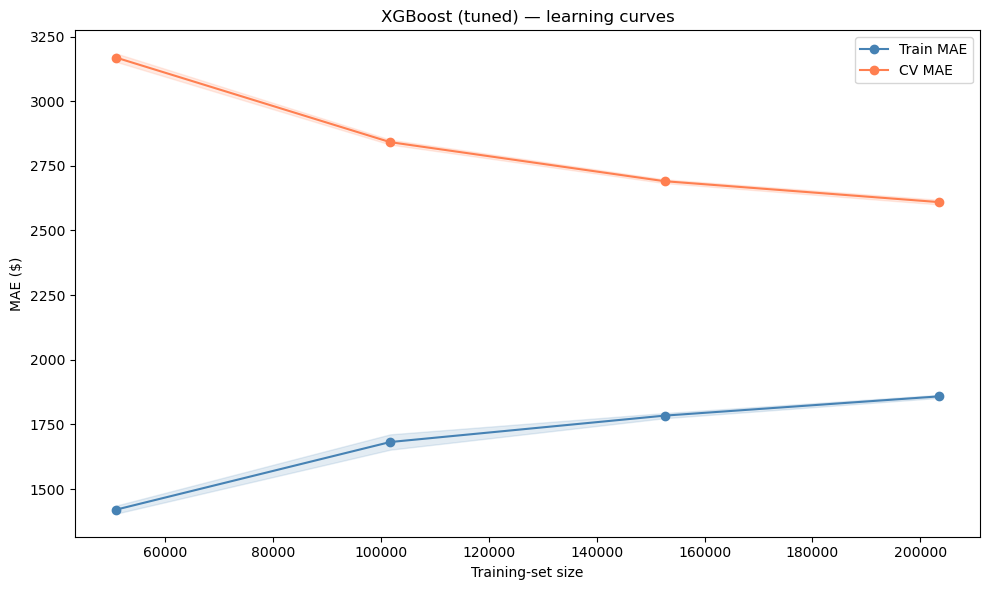

In [8]:
from sklearn.model_selection import learning_curve

print("Computing learning curves (4 train sizes x 3 folds = 12 fits) ...")
t0 = time.perf_counter()
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.25, 1.0, 4),
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
print(f"  done in {(time.perf_counter() - t0)/60:.1f} min")

train_m = -train_scores.mean(axis=1); train_s = train_scores.std(axis=1)
test_m  = -test_scores.mean(axis=1);  test_s  = test_scores.std(axis=1)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes_abs, train_m - train_s, train_m + train_s, alpha=0.15, color="steelblue")
ax.fill_between(train_sizes_abs, test_m - test_s,   test_m + test_s,   alpha=0.15, color="coral")
ax.plot(train_sizes_abs, train_m, "o-", color="steelblue", label="Train MAE")
ax.plot(train_sizes_abs, test_m,  "o-", color="coral",     label="CV MAE")
ax.set_xlabel("Training-set size")
ax.set_ylabel("MAE ($)")
ax.set_title("XGBoost (tuned) — learning curves")
ax.legend()
plt.tight_layout()
plt.show()


## 3C.9 — Feature Selection Experiment *(issue #18)*

> *Optional — `niceToHave`. The cross-model comparison (full vs reduced on test set) lives in §04 per the issue spec; this section only does the refit and save.*

Embedded selection: keep features whose importance from §3C.6 is at or above the median (i.e., the top half of the 32 features). Refit XGBoost on those alone with the same tuned hyperparameters, save as `models/xgboost_reduced.pkl`.

The selection is embedded *after* the preprocessor (so we never re-do imputation/encoding) by composing a custom column-index selector — `SelectFromModel` works too but pinning to a fixed index list keeps the saved pipeline deterministic.


Refitting XGBoost on reduced (top-half) feature set ...


  done in 5.5s

Kept 16/32 features:
  - year__year
  - odo__odometer
  - ohe__fuel_gas
  - ohe__fuel_other
  - ohe__transmission_other
  - ohe__drive_fwd
  - ohe__drive_rwd
  - ohe__type_hatchback
  - ohe__type_other
  - ohe__type_pickup
  - ohe__type_truck
  - ohe__type_van
  - ohe__title_status_rebuilt
  - ohe__title_status_salvage
  - target__manufacturer
  - target__model



Reduced-feature CV MAE (3-fold): $2,789.44 ± $22.09
Tuned full-feature CV MAE (5-fold, S3C.5): $2,555.15 ± $16.16



Saved -> models/xgboost_reduced.pkl


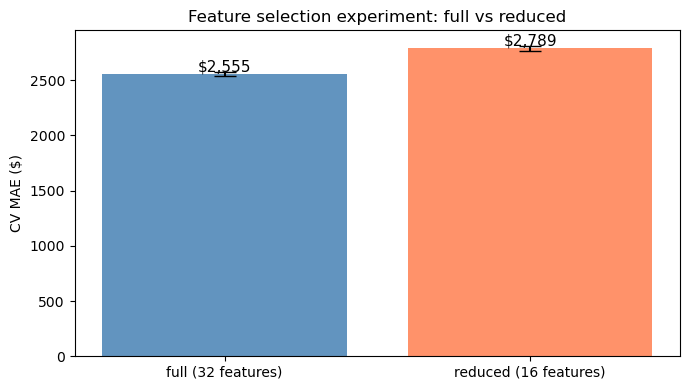

In [9]:
from sklearn.feature_selection import SelectFromModel

# Strip 'est__' prefix from the tuned hyperparameters so we can reuse them
# directly in a fresh XGBRegressor.
best_params_clean = {k.removeprefix("est__"): v for k, v in xgb_search.best_params_.items()}

# Refit on the reduced feature set.
# SelectFromModel(prefit=True) uses the already-fitted estimator's feature
# importances, threshold='median' keeps the top half (16 of 32 features).
# SelectFromModel with prefit=True is NOT Pipeline-compatible (Pipeline.fit
# would call .fit() on each step, but prefit=True selectors are transform-only).
# Workaround: pass a fresh, unfitted XGBRegressor and let SelectFromModel fit
# its own copy during pipeline.fit() to compute importances. ~30s extra cost.
reduced_pipeline = Pipeline([
    ("prep", clone(preprocessor_tree)),
    ("select", SelectFromModel(
        estimator=xgb.XGBRegressor(
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            n_estimators=200,
            max_depth=6,
        ),
        threshold="median",
    )),
    ("est", xgb.XGBRegressor(
        tree_method="hist",
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        **best_params_clean,
    )),
])

print("Refitting XGBoost on reduced (top-half) feature set ...")
t0 = time.perf_counter()
reduced_pipeline.fit(X_train, y_train)
print(f"  done in {time.perf_counter() - t0:.1f}s")

# Identify which features the selector actually kept (the booleans are post-prep)
selected_mask = reduced_pipeline.named_steps["select"].get_support()
selected_features = feat_names[selected_mask]
print(f"\nKept {selected_mask.sum()}/{len(feat_names)} features:")
for f in selected_features:
    print(f"  - {f}")

# Quick CV sanity check so this section reports its own number
res_reduced = cross_validate(
    reduced_pipeline, X_train, y_train,
    cv=3,
    scoring={"mae": "neg_mean_absolute_error"},
    n_jobs=-1,
)
reduced_mae = -res_reduced["test_mae"]
print(f"\nReduced-feature CV MAE (3-fold): ${reduced_mae.mean():,.2f} \u00b1 ${reduced_mae.std():,.2f}")
print(f"Tuned full-feature CV MAE (5-fold, S3C.5): ${tuned_mae.mean():,.2f} \u00b1 ${tuned_mae.std():,.2f}")

# Save -- the actual full-vs-reduced comparison on the held-out test set
# happens in S04.
joblib.dump(reduced_pipeline, MODELS_DIR / "xgboost_reduced.pkl")
print(f"\nSaved -> models/xgboost_reduced.pkl")


# Visual comparison: full vs reduced CV MAE. The proper test-set comparison
# lives in S04, but a quick CV-MAE bar makes the experiment legible at a glance
# in the presentation deck.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
labels = [f"full ({len(feat_names)} features)",
          f"reduced ({selected_mask.sum()} features)"]
values = [tuned_mae.mean(), reduced_mae.mean()]
errors = [tuned_mae.std(),  reduced_mae.std()]
bars = ax.bar(labels, values, yerr=errors, capsize=8,
              color=["steelblue", "coral"], alpha=0.85)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"${v:,.0f}",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("CV MAE ($)")
ax.set_title("Feature selection experiment: full vs reduced")
plt.tight_layout()
plt.show()


## 3C.10 — Save Model

Serialize the tuned XGBoost pipeline to `models/xgboost.pkl` (canonical name; §04 hard-codes this path). Also write `models/xgb_tuning_results.json` with the search summary — same structure as Aybars's `rf_tuning_results.json` so §04 can present them side by side.


In [10]:
# Canonical path -- S04 (evaluation) loads exactly this filename.
save_path = MODELS_DIR / "xgboost.pkl"
joblib.dump(best_pipeline, save_path)
print(f"Saved -> models/{save_path.name}")

# Tuning results sidecar JSON for cross-model comparison in S04.
import json as _json
tuning_results = {
    "best_params": best_params_clean,
    "best_cv_mae":     float(tuned_mae.mean()),
    "best_cv_mae_std": float(tuned_mae.std()),
    "baseline_cv_mae": float(baseline_mae.mean()),
    "improvement_over_baseline": float(baseline_mae.mean() - tuned_mae.mean()),
    "n_iter": int(xgb_search.cv_results_["mean_test_score"].shape[0]),
    "search_time_seconds": float(search_time),
}
with open(MODELS_DIR / "xgb_tuning_results.json", "w") as f:
    _json.dump(tuning_results, f, indent=2)
print(f"Saved -> models/xgb_tuning_results.json")


Saved -> models/xgboost.pkl
Saved -> models/xgb_tuning_results.json
